# TLS Traffic Anomaly Detection System Using Autoencoders with LSTM Enhancement
---

This notebook implements an advanced system for analyzing TLS (Transport Layer Security) traffic patterns and detecting anomalies through a hybrid neural network approach combining autoencoders with LSTM (Long Short-Term Memory) networks.

The system processes TLS records from JSON files and extracts two key types of features:

1. Static features including cipher suites (top 30), client extensions (top 20), cipher groups (top 20), client supported versions (top 5), ALPN protocols (top 5), server extensions (top 10), and server supported versions (top 2), which are processed by extracting the most frequent values and creating binary indicators
2. Sequential record features (tls.rec), which are now handled by LSTM layers to better capture temporal patterns in the data

## Install Python libraries

Install the following Python libraries if not already available in the current kernel.

In [1]:
!pip install matplotlib
!pip install tensorflow
!pip install scikit-learn

## Setup and Imports

In [2]:
import math
import json
import glob
import os
import time
from datetime import datetime
from collections import Counter
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

from keras import layers
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model, load_model, model_from_json
from tensorflow.keras.layers import Input, Dense, LSTM, RepeatVector, TimeDistributed, Masking

## Constants and Global Variables

In [3]:
# TLS Records processing constants
RECORD_SEQUENCE_SIZE = 20  # Maximum length for tls.rec sequences
REC_LATENT_DIM = 16   # Dimension for tls.rec latent representation
TLS_COLUMNS_NAMES = np.array([f"tls.rec.{i}" for i in range(RECORD_SEQUENCE_SIZE)])

# Set constants for the number of top values to use for each feature
TOP_N_CCS = 30 # Cipher suites
TOP_N_CEXT = 20  # Client extensions
TOP_N_CSG = 20  # Cipher groups
TOP_N_CSV = 5   # Client supported versions
TOP_N_ALPN = 5  # ALPN protocols
TOP_N_SEXT = 10  # Server extensions
TOP_N_SSV = 2   # Server supported versions

# Initialize global variables for consistent feature extraction
global_top_ccs = None
global_top_cext = None
global_top_csg = None
global_top_csv = None
global_top_alpn = None
global_top_sext = None
global_top_ssv = None

global_tls_rec_encoder = None
global_tls_rec_scaler = None

## Utility Functions
### Composite Number and Dimension Utilities
These functions help determine optimal dimensions for visualizing high-dimensional data as 2D images.

In [4]:
def is_composite(x):
    """Return True if x is composite (not prime) and x >= 4; otherwise False."""
    if x < 4:
        return False  # 2 and 3 are prime; 1 is neither prime nor composite
    for i in range(2, int(math.sqrt(x)) + 1):
        if x % i == 0:
            return True
    return False


def find_nearest_composites(n):
    """Return the composite numbers greater than n."""
    candidates = []
    for i in range(n, int(n * 3 / 2)):
        if is_composite(i):
            candidates.append(i)
    return candidates


def greatest_divisor_pair(x):
    """
    Return the pair of divisors (d, x//d) for composite x such that
    d is the greatest divisor not exceeding sqrt(x). This pair is closest to each other.
    """
    d = int(math.sqrt(x))
    while d > 1:
        if x % d == 0:
            return (d, x // d)
        d -= 1
    return (1, x)


def get_padding_and_dim(x):
    """
    Find optimal dimensions for visualization by finding the nearest composite number
    that can be factored into dimensions with minimal difference.
    """
    dif = x
    val_x = x
    val_d1 = 0
    val_d2 = 0
    for nearest in find_nearest_composites(x):
        d1, d2 = greatest_divisor_pair(nearest)  
        if (math.fabs(d1-d2) > dif):
            return (val_x, val_d1, val_d2)
        else:
            val_x = nearest
            val_d1 = d1
            val_d2 = d2
            dif = math.fabs(d1-d2) 
    return (val_x, val_d1, val_d2)

def resize_row(row, maxlen, pad_value=0):
    """Resize a row in the array to the specified length."""
    current_length = len(row)
    if current_length < maxlen:
        # Calculate the amount of padding needed
        pad_width = maxlen - current_length
        # Pad at the end
        row = np.pad(row, pad_width=(0, pad_width), mode='constant', constant_values=pad_value)
    else:
        # If the row is longer than the target length, slice it
        row = row[:maxlen]
    return row

def make_image_from_sample(sample, image_pad, image_dim_x, image_dim_y):
    """Convert a sample vector to a 2D image representation for visualization."""
    return np.pad(sample, pad_width=(0, image_pad), mode='constant', constant_values=0).reshape(image_dim_x, image_dim_y)

## TLS Records (tls.rec) Processing

These functions handle processing TLS record sequences using LSTM autoencoders for dimensionality reduction.

In [5]:
def pad_sequences(sequences, maxlen, padding='post', truncating='post', pad_value=0):
    """
    Pads sequences to the same length.
    """
    num_samples = len(sequences)
    padded_sequences = np.full((num_samples, maxlen), pad_value, dtype=float)
    
    for i, seq in enumerate(sequences):
        if not isinstance(seq, (list, np.ndarray)):
            continue
            
        seq = np.asarray(seq)
        if len(seq) == 0:
            continue
            
        if len(seq) >= maxlen:
            if truncating == 'pre':
                padded_sequences[i] = seq[-maxlen:]
            else:
                padded_sequences[i] = seq[:maxlen]
        else:
            if padding == 'pre':
                padded_sequences[i, -len(seq):] = seq
            else:
                padded_sequences[i, :len(seq)] = seq
                
    return padded_sequences

def normalize_tls_rec_data(data, method='standard'):
    """
    Normalize TLS record data.
    """
    original_shape = data.shape
    flattened = data.reshape(-1, 1)
    
    if method == 'standard':
        scaler = StandardScaler()
    elif method == 'minmax':
        scaler = MinMaxScaler(feature_range=(-1, 1))
    else:
        from sklearn.preprocessing import RobustScaler
        scaler = RobustScaler()
    
    # Fit and transform
    normalized = scaler.fit_transform(flattened)
    
    # Reshape back
    normalized = normalized.reshape(original_shape)
    
    return normalized, scaler

def build_tls_rec_autoencoder(max_length=RECORD_SEQUENCE_SIZE, latent_dim=REC_LATENT_DIM):
    """
    Build an LSTM-based autoencoder for TLS record sequences.
    """
    # Input layer
    inputs = Input(shape=(max_length,))
    
    # Reshape for LSTM
    reshaped = tf.keras.layers.Reshape((max_length, 1))(inputs)
    
    # Add masking layer to handle variable length sequences
    masked = Masking(mask_value=0.0)(reshaped)
    
    # Encoder
    encoded = LSTM(64, return_sequences=True)(masked)
    encoded = LSTM(32)(encoded)
    encoded = Dense(latent_dim, activation='tanh')(encoded)
    
    # Decoder
    decoded = RepeatVector(max_length)(encoded)
    decoded = LSTM(32, return_sequences=True)(decoded)
    decoded = LSTM(64, return_sequences=True)(decoded)
    decoded = TimeDistributed(Dense(1))(decoded)
    
    # Flatten back to original shape
    output = tf.keras.layers.Reshape((max_length,))(decoded)
    
    # Create models
    lstm_autoencoder = Model(inputs, output)
    encoder = Model(inputs, encoded)
    
    # Compile the model
    lstm_autoencoder.compile(optimizer='adam', loss='mse')
    
    return lstm_autoencoder, encoder

def train_tls_rec_autoencoder(tls_rec_data, max_length=RECORD_SEQUENCE_SIZE, latent_dim=REC_LATENT_DIM, 
                              epochs=50, batch_size=32, validation_split=0.2):
    """
    Train the LSTM autoencoder on TLS record data.
    """
    # Filter out None or empty lists
    valid_sequences = [seq for seq in tls_rec_data if isinstance(seq, list) and len(seq) > 0]
    
    # Pad sequences
    padded_sequences = pad_sequences(valid_sequences, maxlen=max_length)
    
    # Normalize data
    normalized_data, scaler = normalize_tls_rec_data(padded_sequences, method='standard')
    
    # Build model
    lstm_autoencoder, encoder = build_tls_rec_autoencoder(max_length, latent_dim)
    
    # Print model summary
    lstm_autoencoder.summary()
    
    # Train model
    history = lstm_autoencoder.fit(
        normalized_data, normalized_data,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        verbose=1
    )

    return lstm_autoencoder, encoder, scaler, history

def extract_tls_rec_features(tls_rec_data, encoder, scaler, max_length=RECORD_SEQUENCE_SIZE):
    """
    Extract latent features from TLS record data using the trained encoder.
    """
    # Filter out None or empty lists
    valid_sequences = [seq for seq in tls_rec_data if isinstance(seq, list) and len(seq) > 0]
    
    # Handle empty input
    if not valid_sequences:
        return np.zeros((len(tls_rec_data), REC_LATENT_DIM))
    
    # Pad sequences
    padded_sequences = pad_sequences(valid_sequences, maxlen=max_length)
    
    # Normalize data using the provided scaler
    original_shape = padded_sequences.shape
    flattened = padded_sequences.reshape(-1, 1)
    normalized = scaler.transform(flattened)
    normalized = normalized.reshape(original_shape)
    
    # Extract features using the encoder
    features = encoder.predict(normalized)
    
    # Create a mapping back to original indices
    result = np.zeros((len(tls_rec_data), REC_LATENT_DIM))
    valid_indices = [i for i, seq in enumerate(tls_rec_data) if isinstance(seq, list) and len(seq) > 0]
    
    for i, orig_idx in enumerate(valid_indices):
        result[orig_idx] = features[i]
    
    return result

In [6]:
def create_standardized_column_names(feature_name, values):
    """
    Create standardized column names for binary features.
    
    Parameters:
    -----------
    feature_name : str
        The base feature name (e.g. 'tls.ccs')
    values : list
        List of values to create column names for
    
    Returns:
    --------
    list
        List of standardized column names
    """
    # Remove any trailing dot to ensure consistent format
    if feature_name.endswith('.'):
        feature_name = feature_name[:-1]
    
    # Create standardized column names with consistent format
    return [f"{feature_name}.{val}" for val in values]

def find_top_values(df, column_name, top_n):
    """
    Find the most common values in a list-type column.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataset to analyze
    column_name : str
        Name of the column to analyze
    top_n : int
        Number of top values to return
    
    Returns:
    --------
    list
        List of the top N most common values
    """
    # Check if column exists
    if column_name not in df.columns:
        print(f"WARNING: Column '{column_name}' not found in dataframe")
        return []
        
    all_values = []
    
    # Process all non-null values in the column
    for value_list in df[column_name].dropna():
        # Handle list values
        if isinstance(value_list, list):
            all_values.extend(value_list)
        # Handle string values (that might be lists)
        elif isinstance(value_list, str):
            try:
                # Try to parse as JSON list
                parsed_list = json.loads(value_list.replace("'", '"'))
                if isinstance(parsed_list, list):
                    all_values.extend(parsed_list)
                else:
                    all_values.append(value_list)
            except:
                # Not valid JSON, treat as single value
                all_values.append(value_list)
    
    # Calculate frequency and get top values
    value_counter = Counter(all_values)
    top_values = [val for val, _ in value_counter.most_common(top_n)]
    
    # print(f"Top {len(top_values)} values for {column_name}: {top_values}")
    return top_values

def create_binary_features(row, top_values):
    # Handle non-list values
    if not isinstance(row, list):
        return [0] * len(top_values)
    
    # Create binary indicators
    return [1 if val in row else 0 for val in top_values]

def initialize_global_values(feature_name, values):
    # Get the variable suffix from the feature name
    suffix = feature_name.split('.')[-1]
    
    # Set the global variable
    globals()[f"global_top_{suffix}"] = values
    print(f"{feature_name} values: {len(values)}")



In [7]:
# def find_top_ccs_values(df, top_n):
#     """
#     Find the most common cipher suite values in the dataset.
#     Returns a list of the top N most common values.
#     """
#     all_ccs = []
#     for ccs_list in df['tls.ccs'].dropna():
#         if isinstance(ccs_list, list):
#             all_ccs.extend(ccs_list)
    
#     # Calculate the frequency of each CCS value
#     ccs_counter = Counter(all_ccs)
    
#     # Get the most common CCS values
#     top_ccs = [ccs for ccs, _ in ccs_counter.most_common(top_n)]
    
#     print(f"Top {top_n} cipher suites: {top_ccs}")
#     return top_ccs

# def create_ccs_features(row, top_ccs):
#     """
#     Create binary features for each cipher suite in the top_ccs list.
#     Returns a list of 0s and 1s indicating presence/absence of each cipher suite.
#     """
#     if not isinstance(row, list):
#         return [0] * len(top_ccs)
    
#     # Create a binary feature for each cipher suite
#     return [1 if ccs in row else 0 for ccs in top_ccs]

# def initialize_global_top_ccs(top_ccs):
#     """Initialize the global top CCS list for consistent feature extraction."""
#     global global_top_ccs
#     global_top_ccs = top_ccs
#     print(f"Initialized global top CCS list with {len(global_top_ccs)} values")

## Data Loading and Feature Extraction

In [ ]:
def load_json_files(json_files):
    """
    Load data from the specified collection of JSON files.
    Returns raw data as a DataFrame.
    """
    all_data = []
    file_count = 0
    
    # Open each file and read each line
    for filename in json_files:
        try:
            with open(filename, "r") as file:
                # Load each line as a JSON object
                data = [json.loads(line.strip()) for line in file]
                all_data.extend(data)
                file_count += 1
        except Exception as e:
            print(f"Error processing {filename}: {e}")
    
    print(f"Loaded {len(all_data)} records from {file_count} files")
    
    # Convert the list of dictionaries into a DataFrame
    df = pd.DataFrame(all_data)
    return df

def extract_features(df, use_global=True, use_lstm_encoder=True):
    """
    Extract features from the raw dataset with enhanced TLS feature processing.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Raw dataset to extract features from
    use_global : bool
        Whether to use globally stored feature sets
        
    Returns:
    --------
    dataset : pandas DataFrame
        Processed dataset with all features
    top_values : dict
        Dictionary of top values for each feature type
    """
    global global_tls_rec_encoder, global_tls_rec_scaler
    global global_top_ccs, global_top_cext, global_top_csg
    global global_top_csv, global_top_alpn, global_top_sext, global_top_ssv
    
    # Configuration for feature extraction
    feature_config = {
        'tls.ccs': {'top_n': TOP_N_CCS, 'global_var': global_top_ccs},
        'tls.cext': {'top_n': TOP_N_CEXT, 'global_var': global_top_cext},
        'tls.csg': {'top_n': TOP_N_CSG, 'global_var': global_top_csg},
        'tls.csv': {'top_n': TOP_N_CSV, 'global_var': global_top_csv},
        'tls.alpn': {'top_n': TOP_N_ALPN, 'global_var': global_top_alpn},
        'tls.sext': {'top_n': TOP_N_SEXT, 'global_var': global_top_sext},
        'tls.ssv': {'top_n': TOP_N_SSV, 'global_var': global_top_ssv}
    }
    
    # Dictionary to store top values and DataFrames
    top_values = {}
    feature_dfs = []

    # Process flow data
    flow_data = df[['bs', 'ps', 'br', 'pr', 'td']].astype(float)
    feature_dfs.append(flow_data)
    
    # Process TLS handshake data
    tls_data = df[['tls.cver','tls.sver','tls.scs']].fillna(0).astype(str) 
    feature_dfs.append(tls_data)
    
    # Process TLS records based on configuration
    if use_lstm_encoder and 'tls.rec' in df.columns:
        # Check if we need to train the encoder or if we can use an existing one
        if global_tls_rec_encoder is None or global_tls_rec_scaler is None:
            print("Training LSTM autoencoder for tls.rec features...")
            _, encoder, scaler, _ = train_tls_rec_autoencoder(
                df['tls.rec'].values, 
                max_length=RECORD_SEQUENCE_SIZE,
                latent_dim=REC_LATENT_DIM,
                batch_size=16,
                validation_split=0.2,
                epochs=20 
            )
            global_tls_rec_encoder = encoder
            global_tls_rec_scaler = scaler
            print("LSTM autoencoder training complete")
        
        print(f"tls.rec.values: {df['tls.rec'].values}")

        # Extract LSTM-encoded features
        tls_rec_features = extract_tls_rec_features(
            df['tls.rec'].values,
            global_tls_rec_encoder,
            global_tls_rec_scaler
        )

        print(f"Extracted LSTM-encoded features with shape: {tls_rec_features.shape}")
        
        # Create a DataFrame with the encoded features
        rec_columns = [f'tls.rec.encoded.{i}' for i in range(REC_LATENT_DIM)]
        records_data = pd.DataFrame(tls_rec_features, columns=rec_columns)
        feature_dfs.append(records_data)
    else:
        # Use the original simple padding approach
        records_data = pd.DataFrame(
            pad_sequences(df['tls.rec'].values, maxlen=RECORD_SEQUENCE_SIZE), 
            columns=TLS_COLUMNS_NAMES
        )
        feature_dfs.append(records_data)
    
    # Process each list-type TLS feature
    for feature_name, config in feature_config.items():
        # Determine which values to use (global or from this dataset)
        if use_global and config['global_var'] is not None:
            top_values[feature_name] = config['global_var']
            print(f"Using global {feature_name} list with {len(config['global_var'])} values")
        else:
            # Extract top values from this dataset
            top_values[feature_name] = find_top_values(df, feature_name, config['top_n'])
            
            # Initialize global variables if first run
            if config['global_var'] is None:
                initialize_global_values(feature_name, top_values[feature_name])
        
        # Skip if no values found
        if not top_values[feature_name]:
            continue
        
        # Create column names with standardized format
        column_names = create_standardized_column_names(feature_name, top_values[feature_name])
        
        # Handle missing columns
        if feature_name not in df.columns:
            print(f"WARNING: {feature_name} not in dataframe. Creating dummy features.")
            dummy_features = pd.DataFrame(0, index=df.index, columns=column_names)
            feature_dfs.append(dummy_features)
            continue
        
        # Create binary features
        binary_features = df[feature_name].apply(
            lambda x: create_binary_features(x, top_values[feature_name])
        )
        
        # Convert to DataFrame with proper column names
        feature_df = pd.DataFrame(binary_features.tolist(), columns=column_names, index=df.index)
        feature_dfs.append(feature_df)
        
    # Combine all features into a single dataset
    dataset = pd.concat(feature_dfs, axis=1).fillna(0)
    print(f"Combined features: {dataset.shape}")
    
    return dataset, top_values

def fit_preprocessor(df, top_values, use_lstm_encoder=True):
    """
    Create and fit a preprocessing pipeline for the extracted features.
    
    This pipeline includes:
    - MinMaxScaler for numerical features
    - OneHotEncoder for categorical features
    
    Returns the fitted pipeline that can be used for transforming data.
    """
    transformers = []

    # Define transformers based on whether LSTM encoding is used
    if use_lstm_encoder:
        rec_columns = [f'tls.rec.encoded.{i}' for i in range(REC_LATENT_DIM)]
        
        # Create the column transformer
        preprocessor = ColumnTransformer(
            transformers=[
                ('num_flow', MinMaxScaler(), ['bs', 'ps', 'br', 'pr', 'td']),
                ('num_tls_encoded', MinMaxScaler(), rec_columns),
                ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['tls.cver','tls.sver','tls.scs'])
            ])
    else:
        # Create the column transformer for the original approach
        preprocessor = ColumnTransformer(
            transformers=[
                ('num_flow', MinMaxScaler(), ['bs', 'ps', 'br', 'pr', 'td']),
                ('num_tls', MinMaxScaler(), TLS_COLUMNS_NAMES),
                ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['tls.cver','tls.sver','tls.scs'])
            ])
    
    # Add transformers for binary features
    for feature_name, values in top_values.items():
        if not values:  # Skip empty value lists
            continue
            
        # Create standardized column names
        column_names = create_standardized_column_names(feature_name, values)
        
        # Verify columns exist in the DataFrame
        missing = [col for col in column_names if col not in df.columns]
        if missing:
            print(f"WARNING: {len(missing)} columns missing for {feature_name}")
            continue
            
        # Add transformer
        transformer_name = f"num_{feature_name.split('.')[-1]}"
        transformers.append((transformer_name, MinMaxScaler(), column_names))

    # Create the column transformer
    preprocessor = ColumnTransformer(transformers=transformers)
    
    # Create the pipeline with the preprocessor
    pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
    
    # Fit the pipeline on the data
    pipeline.fit(df)
    return pipeline

In [9]:
def extract_features_with_consistent_columns(df, use_global=False):
    """
    Extract features and ensure consistent columns for pipeline.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Raw dataset to extract features from
    use_global : bool
        Whether to use global feature settings
        
    Returns:
    --------
    dataset : pandas DataFrame
        Processed dataset with consistent columns
    top_values : dict
        Dictionary of top values
    """
    global pipeline_feature_names
    
    # Extract features
    print(f"Extracting features from {df.shape[0]} samples...")
    dataset, top_values = extract_features(df, use_global=use_global)
    
    # First-time setup (training)
    if not use_global or pipeline_feature_names is None:
        # Store column names for later use
        pipeline_feature_names = list(dataset.columns)
        print(f"Stored {len(pipeline_feature_names)} feature names for consistency")
        return dataset, top_values
    
    # Testing phase - ensure column consistency
    print("Ensuring feature consistency...")
    missing_columns = set(pipeline_feature_names) - set(dataset.columns)
    extra_columns = set(dataset.columns) - set(pipeline_feature_names)
    
    if missing_columns:
        print(f"add {len(missing_columns)} missing columns")
        for col in missing_columns:
            dataset[col] = 0
    
    # delete extra columns
    if extra_columns:
        print(f"delete {len(extra_columns)} extra columns")
        dataset = dataset.drop(columns=list(extra_columns))
    
    dataset = dataset[pipeline_feature_names]
    return dataset, top_values

def debug_pipeline_column_issue(input_df, pipeline_features, debug_mode=True):
    """
    Function to debug and fix column inconsistency issues
    
    Parameters:
    -----------
    input_df : DataFrame
        Input DataFrame
    pipeline_features : list
        List of column names expected by the pipeline
    debug_mode : bool
        Whether to output debug information
        
    Returns:
    --------
    fixed_df : DataFrame
        Fixed DataFrame ensuring all columns exist and are in the correct order
    """
    if debug_mode:
        print("\n=== Starting Column Consistency Debugging ===")
        print(f"Input DataFrame shape: {input_df.shape}")
        print(f"Number of columns in Input DataFrame: {len(input_df.columns)}")
        print(f"Number of columns expected by Pipeline: {len(pipeline_features)}")
    
    # Check for column inconsistency issues
    missing_columns = set(pipeline_features) - set(input_df.columns)
    extra_columns = set(input_df.columns) - set(pipeline_features)
    
    if missing_columns and debug_mode:
        print(f"\nMissing columns ({len(missing_columns)}):")
        print(', '.join(sorted(list(missing_columns))[:10]) + ('...' if len(missing_columns) > 10 else ''))
    
    if extra_columns and debug_mode:
        print(f"\nExtra columns ({len(extra_columns)}):")
        print(', '.join(sorted(list(extra_columns))[:10]) + ('...' if len(extra_columns) > 10 else ''))
    
    # Create a new DataFrame to ensure column names and order match the pipeline's expectations
    try:
        # Method 1: Directly create a new DataFrame and populate it
        fixed_df = pd.DataFrame(0, index=range(len(input_df)), columns=pipeline_features)
        
        # Copy data from the original DataFrame
        for col in pipeline_features:
            if col in input_df.columns:
                fixed_df[col] = input_df[col].values
        
        if debug_mode:
            print(f"\nFixed DataFrame shape: {fixed_df.shape}")
            print(f"Number of columns in Fixed DataFrame: {len(fixed_df.columns)}")
            
        # Verify if the fix was successful
        if set(fixed_df.columns) == set(pipeline_features) and len(fixed_df.columns) == len(pipeline_features):
            if debug_mode:
                print("Column fix successful!")
            return fixed_df
        else:
            if debug_mode:
                print("Warning: Column fix may be incomplete")
            
            # Final check for column order
            missing_after_fix = set(pipeline_features) - set(fixed_df.columns)
            if missing_after_fix and debug_mode:
                print(f"Columns still missing after fix: {missing_after_fix}")
                
            return fixed_df
    except Exception as e:
        if debug_mode:
            print(f"Error during fix: {str(e)}")
        
        # Method 2: If Method 1 fails, use a more conservative approach
        try:
            # Create a DataFrame filled with zeros
            fixed_df = pd.DataFrame(np.zeros((len(input_df), len(pipeline_features))), 
                                   columns=pipeline_features)
            
            # Copy column values from the original DataFrame
            common_cols = set(input_df.columns) & set(pipeline_features)
            for col in common_cols:
                fixed_df[col] = input_df[col].values
                
            if debug_mode:
                print("Backup method fix successful")
            return fixed_df
        except Exception as e2:
            if debug_mode:
                print(f"Backup method also failed: {str(e2)}")
            
            # Method 3: Last resort - return a DataFrame filled with zeros
            print("Warning: Using all-zero data")
            return pd.DataFrame(0, index=range(len(input_df)), columns=pipeline_features)

def get_pipeline_feature_names(pipeline):
    """
    Extract required feature names from a Pipeline object
    
    Parameters:
    -----------
    pipeline : Pipeline
        scikit-learn Pipeline object
        
    Returns:
    --------
    feature_names : list
        List of feature names used by the Pipeline
    """
    try:
        # Attempt to retrieve from Column Transformer
        preprocessor = pipeline.named_steps.get('preprocessor', None)
        if preprocessor and hasattr(preprocessor, 'transformers_'):
            feature_names = []
            
            # Extract column names for each transformer
            for name, transformer, columns in preprocessor.transformers_:
                if columns is not None:
                    feature_names.extend(columns)
            
            return feature_names
    except Exception as e:
        print(f"Failed to extract feature names from Pipeline: {e}")
    
    # If extraction fails, return the value stored in the global variable
    if 'pipeline_feature_names' in globals() and pipeline_feature_names is not None:
        return pipeline_feature_names
    
    print("Warning: Unable to determine Pipeline feature names")
    return []

Dataset shape=(14962, 28)
Using global top CCS list with 30 values
Flow data:             bs    ps        br    pr      td
0       1377.0   6.0    7607.0   9.0   0.221
1      11628.0  10.0    4676.0   9.0   4.470
2       1418.0   6.0    6495.0   7.0   0.060
3       2990.0  12.0    6951.0   7.0   0.544
4       1575.0   7.0   36879.0  16.0   0.048
...        ...   ...       ...   ...     ...
14957   2701.0   5.0  252401.0  35.0   0.057
14958   2862.0   7.0    5181.0   7.0   0.040
14959   5390.0  12.0    9718.0  13.0  25.673
14960   3717.0   9.0    5819.0   8.0   0.057
14961   3327.0   8.0    5117.0   8.0   0.058

[14962 rows x 5 columns]
TLS handshake data:       tls.cver tls.sver tls.scs
0       0x0303   0x0303  0x1301
1       0x0303   0x0303  0xc02b
2       0x0303   0x0303  0x1301
3       0x0303   0x0303  0x1301
4       0x0303   0x0303  0x1301
...        ...      ...     ...
14957   0x0303   0x0303  0x1302
14958   0x0303   0x0303  0x1301
14959   0x0303   0x0303  0x1301
14960   0x0303  

Model: "functional_44"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_32      │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_24          │ (None, 20, 1)     │          0 │ input_layer_32[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_12        │ (None, 20, 1)     │          0 │ reshape_24[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_12          │ (None, 20, 1)     │          0 │ reshape_24[0][0]  │
│ (Masking)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_12 (Any)        │ (None, 20)        │          0 │ not_equal_12[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_48 (LSTM)      │ (None, 20, 64)    │     16,896 │ masking_12[0][0], │
│                     │                   │            │ any_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_49 (LSTM)      │ (None, 32)        │     12,416 │ lstm_48[0][0],    │
│                     │                   │            │ any_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 16)        │        528 │ lstm_49[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_12    │ (None, 20, 16)    │          0 │ dense_44[0][0]    │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_50 (LSTM)      │ (None, 20, 32)    │      6,272 │ repeat_vector_12… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_51 (LSTM)      │ (None, 20, 64)    │     24,832 │ lstm_50[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_12 │ (None, 20, 1)     │         65 │ lstm_51[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_25          │ (None, 20)        │          0 │ time_distributed… │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,009 (238.32 KB)

 Trainable params: 61,009 (238.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - loss: 0.6525 - val_loss: 0.5090
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.4886 - val_loss: 0.4997
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.4257 - val_loss: 0.3457
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 0.3525 - val_loss: 0.3150
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.3198 - val_loss: 0.4471
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.3941 - val_loss: 0.3017
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.3718 - val_loss: 0.2570
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.2726 - val_loss: 0.2190
Epoch 9/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.2395 - val_loss: 0.1926
Epoch 10/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.1751 - val_loss: 0.1955
Epoch 11/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.2054 - val_loss: 0.1286
Epoch 12/50
375/375 ━━━━━━━━━━━

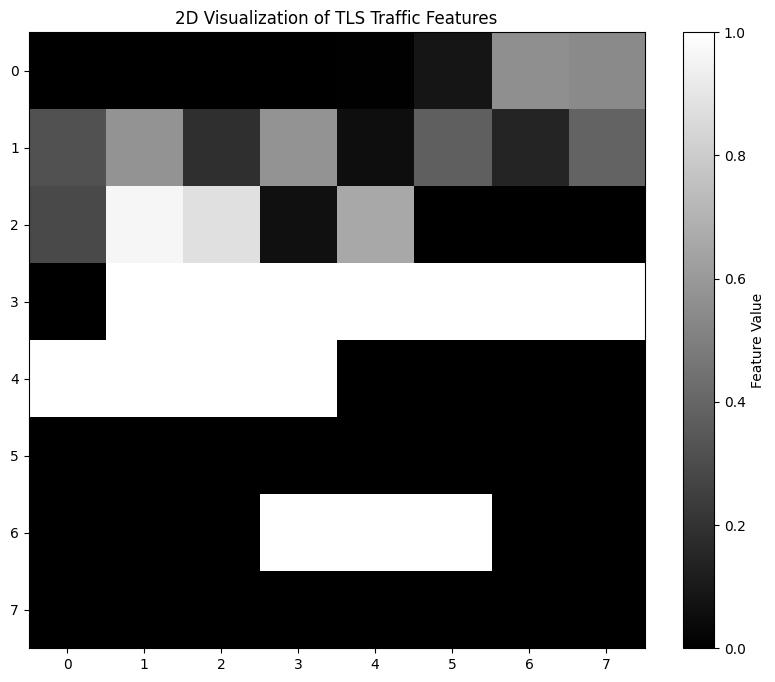

In [ ]:
# Load normal data (desktop application TLS traffic)
raw_df = load_json_files(glob.glob("../datasets/desktop.tls/*.json"))
print(f'Dataset shape={raw_df.shape}')

# Extract features from the raw data
input_df, top_values = extract_features_with_consistent_columns(raw_df, use_global_ccs=True, use_lstm_encoder=True)

# Create and fit the preprocessing pipeline
pipeline = fit_preprocessor(input_df, top_values)

# Transform the data using the pipeline
normal_df = pipeline.transform(input_df)

print('Normalized row of data:')
print(normal_df[0])
print(f'Dataset shape={normal_df.shape}')

# Prepare for visualization
row_len = normal_df.shape[1]
(new_row_len, dim_x, dim_y) = get_padding_and_dim(row_len)
image_pad = new_row_len - row_len
print(f"Visualization adjustment: {row_len} -> {new_row_len} (+ {image_pad}) [{dim_x} x {dim_y}]")

# Create an image representation of the first sample
sample_image = make_image_from_sample(normal_df[0], image_pad, dim_x, dim_y)

## Data Loading and Feature Extraction

Read more: https://www.tensorflow.org/tutorials/generative/autoencoder

In [ ]:

class Autoencoder(Model):
  """
  Autoencoder model for anomaly detection in TLS traffic data.
  """
  def __init__(self, latent_dim, input_dim):
    super(Autoencoder, self).__init__()
    self.latent_dim = latent_dim
    self.input_dim = input_dim
    
    self.encoder = tf.keras.Sequential([
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(latent_dim, activation='relu')
    ])

    self.decoder = tf.keras.Sequential([
        layers.Dense(64, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(input_dim, activation='sigmoid')
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded
    
  def encode(self, x):
    return self.encoder(x)
    
  def decode(self, x):
    return self.decoder(x)
  
def train_autoencoder(x_train, x_test, input_dim, latent_dim=6, epochs=50, batch_size=16):
    """
    Train an autoencoder for anomaly detection.
    
    Parameters:
    -----------
    x_train : numpy array
        Training data
    x_test : numpy array
        Testing data
    input_dim : int
        Input dimension
    latent_dim : int
        Dimension of the latent space
    epochs : int
        Number of training epochs
    batch_size : int
        Batch size for training
        
    Returns:
    --------
    autoencoder : Autoencoder
        Trained autoencoder model
    history : History
        Training history
    training_time : float
        Time taken for training
    """
    # Autoencoder model
    autoencoder = Autoencoder(latent_dim, input_dim)
    
    # Compile and train the autoencoder
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    
    # Start training and measure time
    start_time = time.time()
    history = autoencoder.fit(
        x_train, x_train,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True,
        validation_data=(x_test, x_test),
        verbose=1
    )
    training_time = time.time() - start_time
    
    return autoencoder, history, training_time

def evaluate_autoencoder(autoencoder, x_test):
    """
    Evaluate the autoencoder by calculating reconstruction errors.
    
    Parameters:
    -----------
    autoencoder : Autoencoder
        Trained autoencoder model
    x_test : numpy array
        Test data
        
    Returns:
    --------
    encoded_imgs : numpy array
        Encoded representations of test data
    decoded_imgs : numpy array
        Reconstructed test data
    reconstruction_errors : numpy array
        Reconstruction errors for each test sample
    """
    # Encode and decode the test data
    encoded_imgs = autoencoder.encode(x_test)
    decoded_imgs = autoencoder.decode(encoded_imgs)
    
    # Calculate reconstruction errors
    reconstruction_errors = np.mean(np.square(x_test - decoded_imgs), axis=1)

    # Calculate statistics
    avg_error = np.mean(reconstruction_errors)
    max_error = np.max(reconstruction_errors)
    min_error = np.min(reconstruction_errors)
    
    print(f"Average={avg_error:.6f}, Max={max_error:.6f}, Min={min_error:.6f} reconstruction errors.")
    
    return encoded_imgs, decoded_imgs, reconstruction_errors

def visualize_reconstructions(x_test, decoded_imgs, reconstruction_errors, method_name, make_image_func):
  """
  Visualize original and reconstructed samples with the worst reconstruction errors.
  
  Parameters:
  -----------
  x_test : numpy array
      Original test data
  decoded_imgs : numpy array
      Reconstructed test data
  reconstruction_errors : numpy array
      Reconstruction errors for each test sample
  method_name : str
      Name of the method used for visualization title
  make_image_func : function
      Function to convert a sample to a 2D image
  """
  # Get the 20 samples with the worst reconstruction errors
  worst20 = np.argsort(reconstruction_errors)[-20:][::-1]
  
  n = 20  # Number of samples to display
  i = 0
  
  print(f"Worst reconstructed ({method_name}):")
  plt.figure(figsize=(20, 4))
  for j in worst20:
    reconstruction_error = reconstruction_errors[j]
    original = x_test[j]
    original = make_image_func(original, image_pad, dim_x, dim_y) 
    reconstructed = decoded_imgs[j]
    reconstructed = make_image_func(reconstructed, image_pad, dim_x, dim_y) 
    
    # Original image
    plt.subplot(2, n, i + 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # Reconstructed image
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"RE {reconstruction_error:.3f}")
    plt.axis('off')
    i += 1
  
  plt.suptitle(f"{method_name} Method Reconstructions")
  plt.tight_layout()
  plt.subplots_adjust(top=0.85)
  plt.show()

Training dataset shape: (11969, 61)
Testing dataset shape (normal): (2993, 61)
Epoch 1/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2557 - val_loss: 0.1532
Epoch 2/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1504 - val_loss: 0.1466
Epoch 3/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1445 - val_loss: 0.1420
Epoch 4/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 965us/step - loss: 0.1413 - val_loss: 0.1397
Epoch 5/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 959us/step - loss: 0.1407 - val_loss: 0.1389
Epoch 6/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1397 - val_loss: 0.1390
Epoch 7/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1389 - val_loss: 0.1382
Epoch 8/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 993us/step - loss: 0.1386 - val_loss: 0.1380
Epoch 9/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1384 - val_loss: 0.1379
Epoch 10/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1380 - val_loss: 0.1378
Epoch 11/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step -

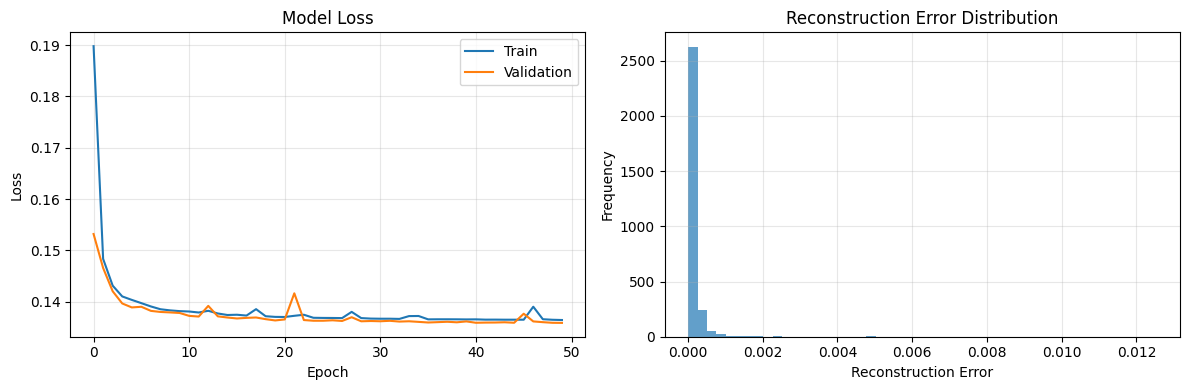

Worst reconstructed (Autoencoder):


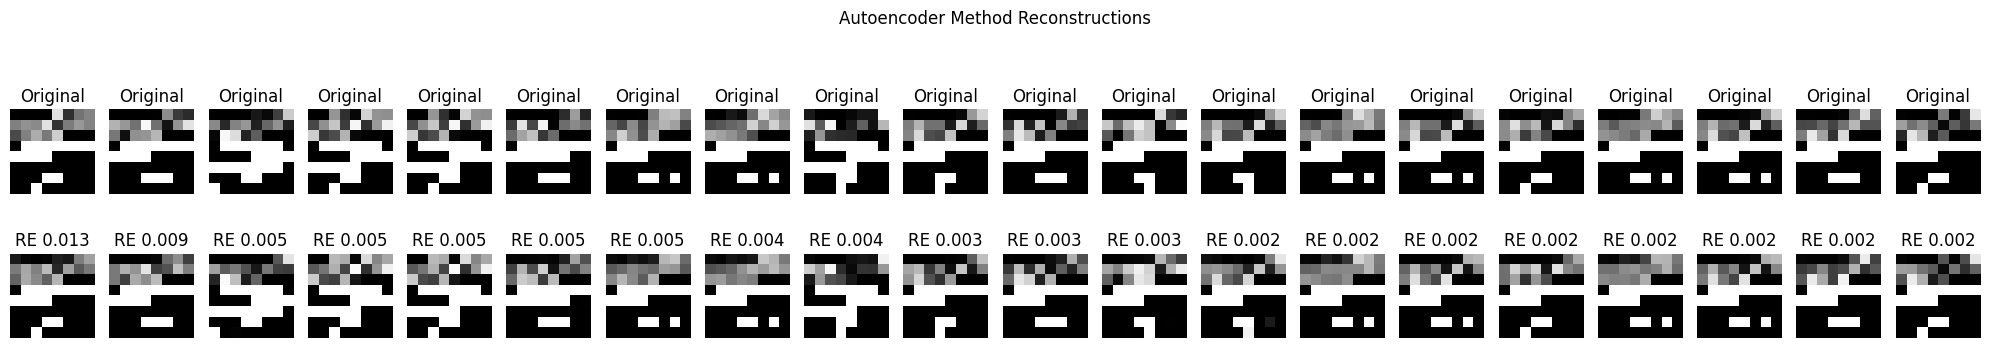

In [237]:
# Set the size of the latent space
LATENT_SPACE_SIZE = 6

# Split data into training and testing sets
x_train, x_test = train_test_split(normal_df, test_size=0.2, random_state=42)
print(f'Training dataset shape: {x_train.shape}')
print(f'Testing dataset shape (normal): {x_test.shape}')

# Define dimensions and architecture
input_dim = x_train.shape[1]
encoding_dim = LATENT_SPACE_SIZE  # Size of the latent space

# Train the autoencoder
autoencoder, history, training_time = train_autoencoder(
    x_train, 
    x_test, 
    input_dim=input_dim, 
    latent_dim=encoding_dim, 
    epochs=50, 
    batch_size=16
)
print(f"Training time: {training_time:.2f} seconds")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True, alpha=0.3)

# Evaluate the autoencoder on test data
encoded_imgs, decoded_imgs, reconstruction_errors = evaluate_autoencoder(autoencoder, x_test)

# Plot error distribution
plt.subplot(1, 2, 2)
plt.hist(reconstruction_errors, bins=50, alpha=0.7)
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize the reconstructions
visualize_reconstructions(x_test, decoded_imgs, reconstruction_errors, "Autoencoder", make_image_from_sample)

## Dataset Testing Function for Anomaly Detection
The following function allows testing different datasets using the trained autoencoder.

In [238]:
def test_dataset(json_files, top_ccs, dataset_name="Unnamed Dataset", export_results=False):
    """
    Test a TLS dataset and print detailed results in English.
    
    Parameters:
    -----------
    json_files : list or glob pattern
        The JSON files containing TLS records to test
    top_ccs : list
        List of top CCS values used during training
    dataset_name : str
        Name of the dataset being tested (for reporting)
    export_results : bool
        Whether to export results to Excel file
    """
    # Start timing
    start_time = time.time()
    
    # Load and process data
    raw_test_df = load_json_files(json_files)
    
    # Find this dataset's own top CCS values (for analysis purposes)
    dataset_top_ccs = find_top_ccs_values(raw_test_df, top_n=TOP_N_CCS)
    print(f"Top 30 cipher suites in {dataset_name}: {dataset_top_ccs}")
    
    # Compare with training dataset's CCS values
    common_ccs = set(dataset_top_ccs) & set(top_ccs)
    unique_ccs = set(dataset_top_ccs) - set(top_ccs)
    print(f"CCS values in common with training data: {len(common_ccs)}")
    print(f"CCS values unique to this dataset: {len(unique_ccs)}")
    if unique_ccs:
        print(f"Unique CCS values: {', '.join(list(unique_ccs)[:10])}")
    
    # Use training top CCS for feature extraction to ensure model compatibility
    input_test_df, _ = extract_features(raw_test_df, use_global_ccs=True, use_lstm_encoder=True)
    
    # Transform data using the pipeline
    test_df = pipeline.transform(input_test_df)
    print(f"Processed dataset shape: {test_df.shape} ({test_df.shape[0]} samples with {test_df.shape[1]} features)")
    
    # Encode and decode using the autoencoder
    encoded_test = autoencoder.encode(test_df)
    decoded_test = autoencoder.decode(encoded_test)
        
    # Calculate reconstruction errors
    test_reconstruction_errors = np.mean(np.square(test_df - decoded_test), axis=1)
    
    # Calculate statistics
    test_avg_error = np.mean(test_reconstruction_errors)
    test_median_error = np.median(test_reconstruction_errors)
    test_std_error = np.std(test_reconstruction_errors)
    test_min_error = np.min(test_reconstruction_errors)
    test_max_error = np.max(test_reconstruction_errors)
    
    # Get percentiles for better distribution understanding
    percentiles = [25, 50, 75, 90, 95, 99]
    error_percentiles = np.percentile(test_reconstruction_errors, percentiles)
    
    # Get best and worst samples
    worst10 = np.argsort(test_reconstruction_errors)[-10:][::-1]
    
    # Calculate elapsed time
    elapsed_time = time.time() - start_time
    
    # Visualize results
    n = 10  # Number of samples to display
    plt.figure(figsize=(20, 4))
    for i, j in enumerate(worst10):
        rec_error = test_reconstruction_errors[j]
        original = test_df[j]
        original = make_image_from_sample(original, image_pad, dim_x, dim_y)  
        reconstructed = decoded_test[j]
        reconstructed = make_image_from_sample(reconstructed, image_pad, dim_x, dim_y)
        
        # Original images
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original, cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        # Reconstructed images
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed, cmap='gray')
        plt.title(f"RE {rec_error:.3f}")
        plt.axis('off')
    
    plt.suptitle(f"Worst Reconstructed Samples - {dataset_name}", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()
    
    # Performance summary
    print("\nPERFORMANCE SUMMARY:")
    print(f"Dataset: {dataset_name}")
    print(f"Number of samples: {raw_test_df.shape[0]}")
    print(f"Number of features: {test_df.shape[1]}")
    print(f"Average reconstruction error: {test_avg_error:.6f}")
    print(f"Processing time: {elapsed_time:.2f} seconds")
    
    # Export results if requested
    if export_results:
        # Prepare results dictionary
        results_dict = {
            'Dataset Name': dataset_name,
            'Timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'Number of Samples': raw_test_df.shape[0],
            'Number of Features': test_df.shape[1],
            'Average Error': test_avg_error,
            'Median Error': test_median_error,
            'Std Deviation': test_std_error,
            'Min Error': test_min_error,
            'Max Error': test_max_error,
            'Processing Time (s)': elapsed_time
        }
        
        # Add percentiles
        for p, val in zip(percentiles, error_percentiles):
            results_dict[f'Percentile {p}'] = val
    
    return {
        'dataset_name': dataset_name,
        'avg_error': test_avg_error,
        'median_error': test_median_error,
        'std_error': test_std_error,
        'min_error': test_min_error,
        'max_error': test_max_error,
        'raw_shape': raw_test_df.shape,
        'processed_shape': test_df.shape,
        'errors': test_reconstruction_errors,
        'top_ccs': dataset_top_ccs
    }

Using global top CCS list with 30 values
Flow data:             bs    ps        br    pr      td
0       1377.0   6.0    7607.0   9.0   0.221
1      11628.0  10.0    4676.0   9.0   4.470
2       1418.0   6.0    6495.0   7.0   0.060
3       2990.0  12.0    6951.0   7.0   0.544
4       1575.0   7.0   36879.0  16.0   0.048
...        ...   ...       ...   ...     ...
14957   2701.0   5.0  252401.0  35.0   0.057
14958   2862.0   7.0    5181.0   7.0   0.040
14959   5390.0  12.0    9718.0  13.0  25.673
14960   3717.0   9.0    5819.0   8.0   0.057
14961   3327.0   8.0    5117.0   8.0   0.058

[14962 rows x 5 columns]
TLS handshake data:       tls.cver tls.sver tls.scs
0       0x0303   0x0303  0x1301
1       0x0303   0x0303  0xc02b
2       0x0303   0x0303  0x1301
3       0x0303   0x0303  0x1301
4       0x0303   0x0303  0x1301
...        ...      ...     ...
14957   0x0303   0x0303  0x1302
14958   0x0303   0x0303  0x1301
14959   0x0303   0x0303  0x1301
14960   0x0303   0x0303  0x1301
14961   0x

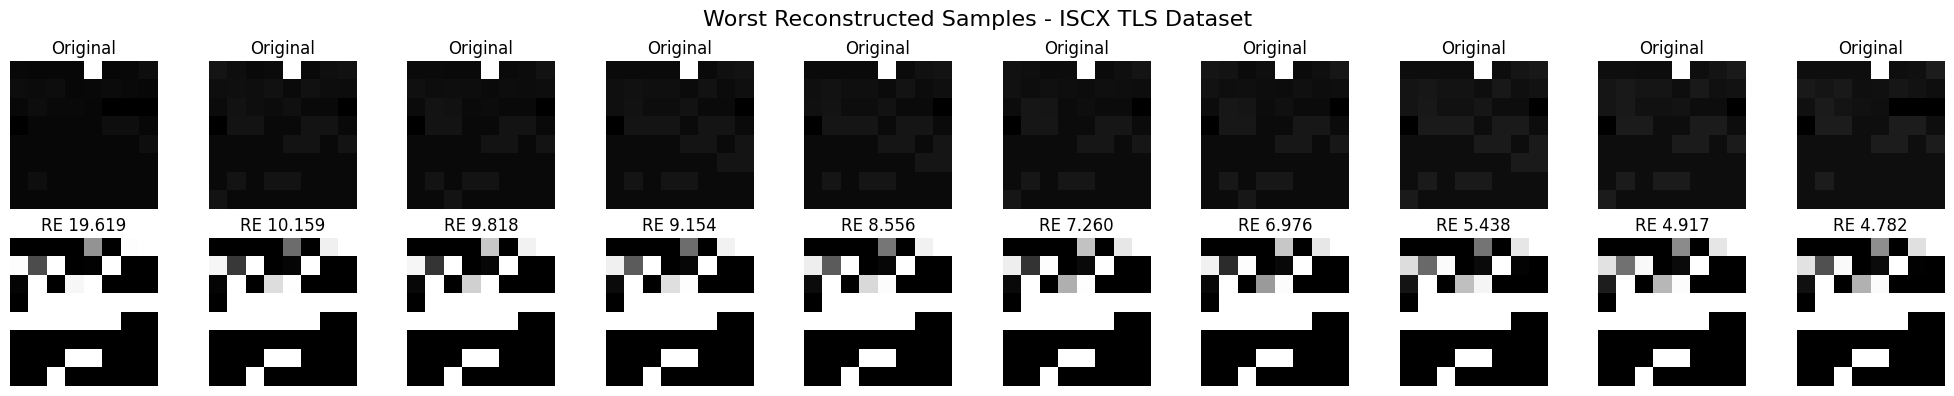


PERFORMANCE SUMMARY:
Dataset: ISCX TLS Dataset
Number of samples: 1112
Number of features: 61
Average reconstruction error: 0.343463
Processing time: 0.31 seconds
Top 30 cipher suites: ['C02B', 'C02F', 'C02C', 'C030', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C013', 'C014', '009C', '002F', '0035', '009D', 'C009', 'C00A', '000A', 'C008', 'C012', 'C024', 'C028', 'C023', 'C027', '003D', '003C', '00FF', '009F', 'CCAA', '009E']
Top 30 cipher suites in Mobile TLS Dataset: ['C02B', 'C02F', 'C02C', 'C030', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C013', 'C014', '009C', '002F', '0035', '009D', 'C009', 'C00A', '000A', 'C008', 'C012', 'C024', 'C028', 'C023', 'C027', '003D', '003C', '00FF', '009F', 'CCAA', '009E']
CCS values in common with training data: 27
CCS values unique to this dataset: 3
Unique CCS values: C008, CCAA, C012
Using global top CCS list with 30 values
Flow data:           bs    ps        br    pr      td
0      994.0   3.0   13793.0  12.0   0.089
1     2301.0   4.0     916.0   4.

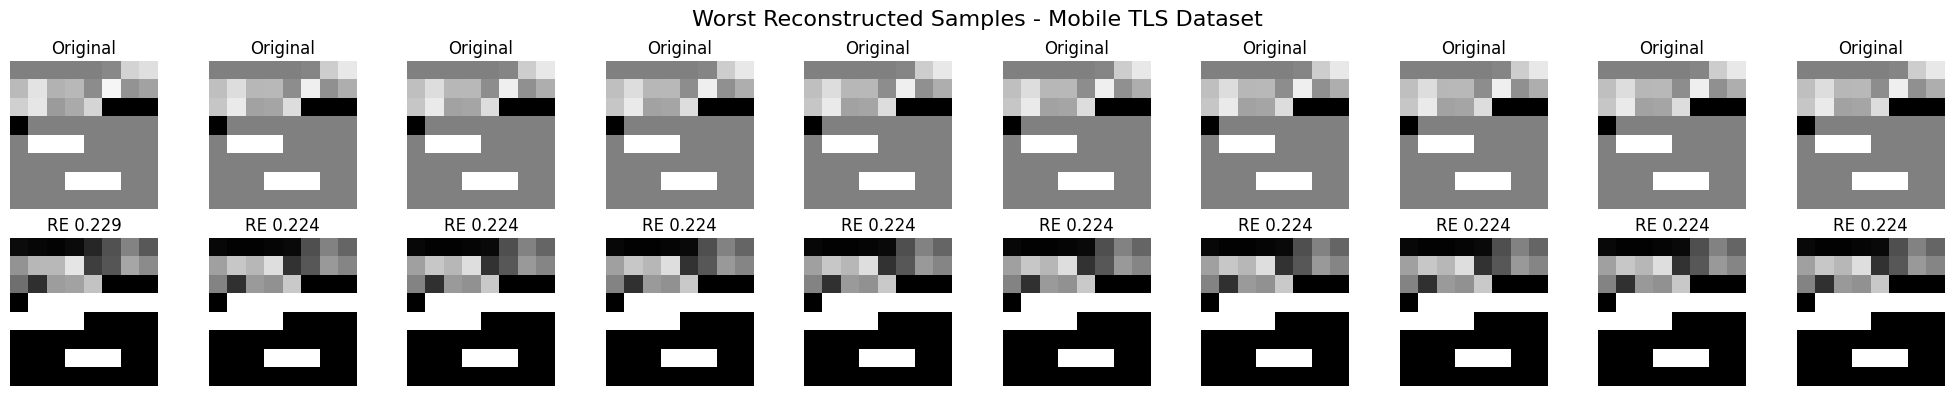


PERFORMANCE SUMMARY:
Dataset: Mobile TLS Dataset
Number of samples: 5616
Number of features: 61
Average reconstruction error: 0.023648
Processing time: 1.00 seconds
Top 30 cipher suites: ['C02C', 'C02B', 'C030', 'C02F', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1302', '1301', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0067', '0039']
Top 30 cipher suites in Windows TLS Dataset: ['C02C', 'C02B', 'C030', 'C02F', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1302', '1301', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0067', '0039']
CCS values in common with training data: 30
CCS values unique to this dataset: 0
Using global top CCS list with 30 values
Flow data:            bs   ps      br   pr     td
0      2702.0  4.0  7275.0  7.0  0.637
1      2235.0  4.0  9039.0  6.0  0.653
2      1668.0  3.0  5338.0  4.0  0.

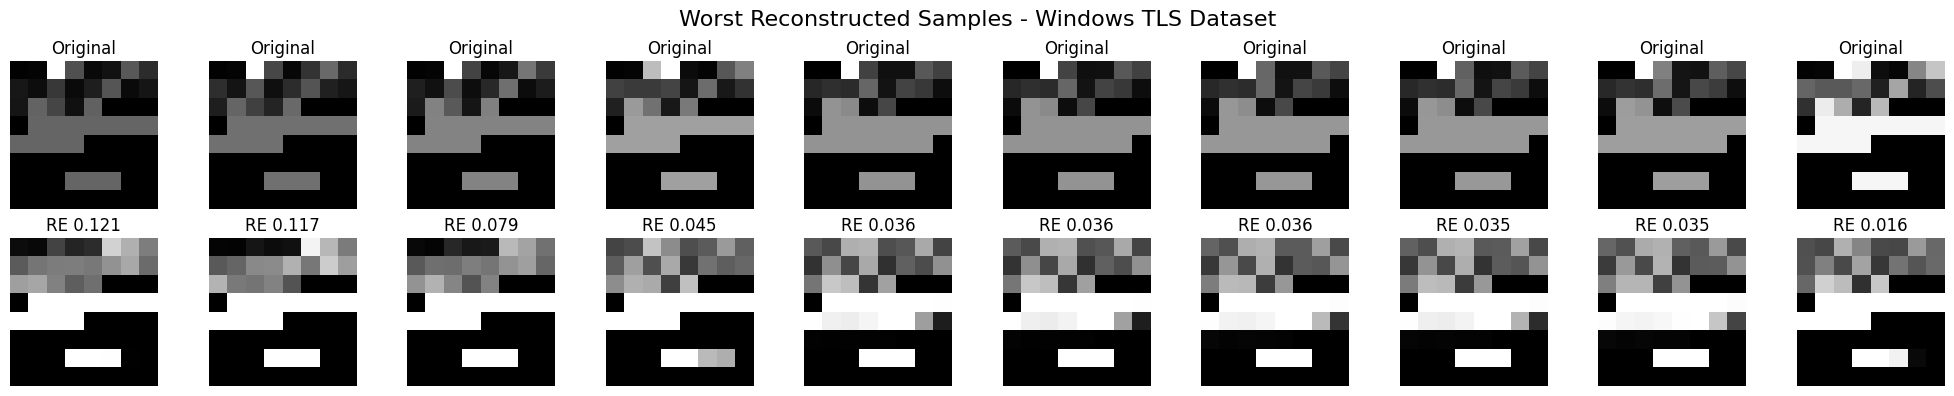


PERFORMANCE SUMMARY:
Dataset: Windows TLS Dataset
Number of samples: 15047
Number of features: 61
Average reconstruction error: 0.000177
Processing time: 2.82 seconds
Top 30 cipher suites: ['002F', '0035', 'C013', 'C014', 'C009', 'C00A', 'C02F', 'C02B', '009C', 'C030', 'C02C', '009D', '0033', '00FF', '0039', '009E', '0005', 'C011', 'C007', '009F', '000A', 'CC14', 'CC13', 'CCA9', 'CCA8', '0004', '0009', '0008', '0003', '0006']
Top 30 cipher suites in CIC-AA Normal TLS Dataset: ['002F', '0035', 'C013', 'C014', 'C009', 'C00A', 'C02F', 'C02B', '009C', 'C030', 'C02C', '009D', '0033', '00FF', '0039', '009E', '0005', 'C011', 'C007', '009F', '000A', 'CC14', 'CC13', 'CCA9', 'CCA8', '0004', '0009', '0008', '0003', '0006']
CCS values in common with training data: 19
CCS values unique to this dataset: 11
Unique CCS values: 0008, 0009, C007, 0003, 0005, CC14, 0006, CC13, 0004, C011
Using global top CCS list with 30 values
Flow data:            bs    ps      br    pr       td
0       831.0   6.0  2

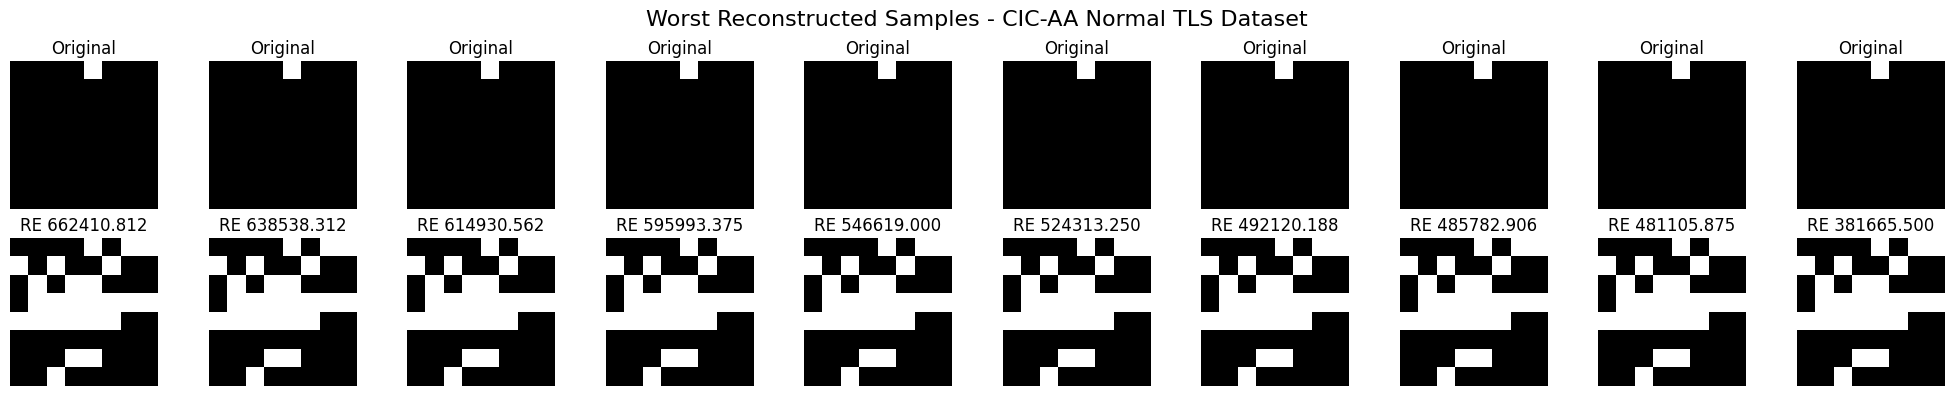


PERFORMANCE SUMMARY:
Dataset: CIC-AA Normal TLS Dataset
Number of samples: 31179
Number of features: 61
Average reconstruction error: 403.877777
Processing time: 7.76 seconds
Top 30 cipher suites: ['002F', '0035', 'C009', 'C00A', 'C013', 'C014', 'C02B', 'C02F', '009C', '0033', '0039', '009E', '00FF', '0005', 'C007', 'C011', 'C02C', 'C030', '009D', '009F', '000A', 'CCA9', 'CCA8', 'CC14', 'CC13', '0004', '0009', '0003', '0006', '0008']
Top 30 cipher suites in CIC-AA Malware TLS Dataset: ['002F', '0035', 'C009', 'C00A', 'C013', 'C014', 'C02B', 'C02F', '009C', '0033', '0039', '009E', '00FF', '0005', 'C007', 'C011', 'C02C', 'C030', '009D', '009F', '000A', 'CCA9', 'CCA8', 'CC14', 'CC13', '0004', '0009', '0003', '0006', '0008']
CCS values in common with training data: 19
CCS values unique to this dataset: 11
Unique CCS values: 0008, 0009, C007, 0003, 0005, CC14, 0006, CC13, 0004, C011
Using global top CCS list with 30 values
Flow data:          bs    ps       br    pr       td
0    1945.0   

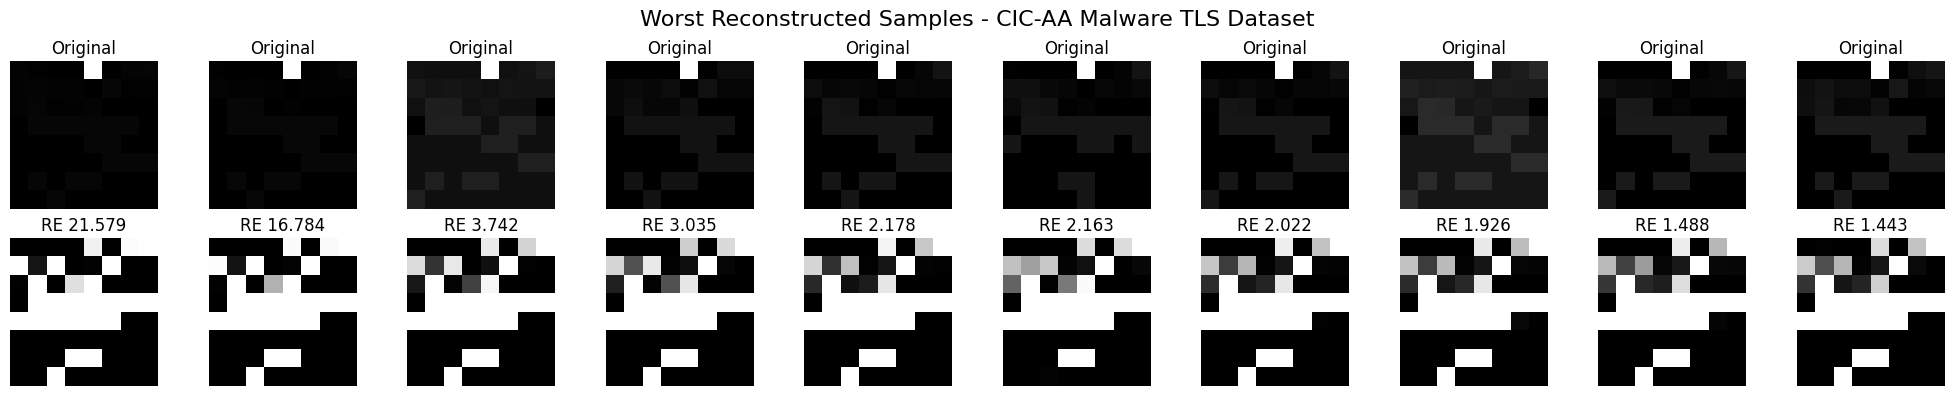


PERFORMANCE SUMMARY:
Dataset: CIC-AA Malware TLS Dataset
Number of samples: 462
Number of features: 61
Average reconstruction error: 0.432546
Processing time: 0.45 seconds
Top 30 cipher suites: ['C02B', 'C02F', '009E', 'C009', 'C00A', 'C013', 'C014', '0033', '0039', '009C', '002F', '0035', '00FF', 'C007', 'C011', '0005', 'C02C', 'C030', '009F', '009D', '000A', 'CC14', 'CC13', 'CC15', '0004', 'C028', 'C024', 'C022', 'C021', '00A3']
Top 30 cipher suites in CIC-AA Adware TLS Dataset: ['C02B', 'C02F', '009E', 'C009', 'C00A', 'C013', 'C014', '0033', '0039', '009C', '002F', '0035', '00FF', 'C007', 'C011', '0005', 'C02C', 'C030', '009F', '009D', '000A', 'CC14', 'CC13', 'CC15', '0004', 'C028', 'C024', 'C022', 'C021', '00A3']
CCS values in common with training data: 19
CCS values unique to this dataset: 11
Unique CCS values: C007, C022, 00A3, 0005, CC14, C021, CC13, 0004, C011, CC15
Using global top CCS list with 30 values
Flow data:            bs    ps      br    pr       td
0      2607.0   5

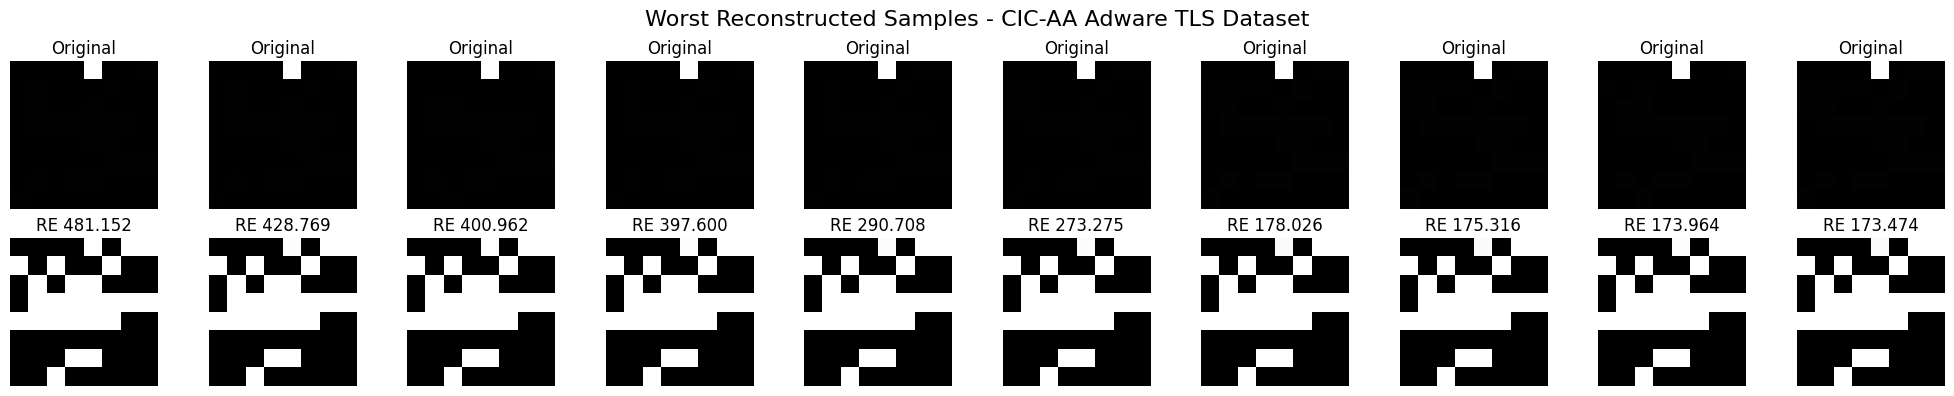


PERFORMANCE SUMMARY:
Dataset: CIC-AA Adware TLS Dataset
Number of samples: 7122
Number of features: 61
Average reconstruction error: 0.965900
Processing time: 1.34 seconds

COMPARISON OF DATASETS
                   Dataset  Samples  Features  Avg Error     Max Error  Min Error
          ISCX TLS Dataset     1112        61   0.343463     19.619276   0.025231
        Mobile TLS Dataset     5616        61   0.023648      0.228928   0.000010
       Windows TLS Dataset    15047        61   0.000177      0.120810   0.000011
 CIC-AA Normal TLS Dataset    31179        61 403.877777 662410.812500   0.003909
CIC-AA Malware TLS Dataset      462        61   0.432546     21.578974   0.034517
 CIC-AA Adware TLS Dataset     7122        61   0.965900    481.152222   0.016841


In [239]:
# Initialize results dictionary
results = {}

# Load normal data and extract features
raw_df = load_json_files(glob.glob("../datasets/desktop.tls/*.json"))
input_df, top_ccs = extract_features(raw_df)

# Test ISCX dataset
results['iscx'] = test_dataset(
    json_files=glob.glob("../datasets/iscx.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="ISCX TLS Dataset",
    export_results=True
)

# Test Mobile dataset
results['mobile'] = test_dataset(
    glob.glob("../datasets/mobile.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="Mobile TLS Dataset",
    export_results=True
)

# Test Windows dataset
results['windows'] = test_dataset(
    glob.glob("../datasets/windows.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="Windows TLS Dataset",
    export_results=True
)

# Test cic-aa.normal datasets
results['cic-aa.normal'] = test_dataset(
    glob.glob("../datasets/cic-aa.normal.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="CIC-AA Normal TLS Dataset",
    export_results=True
)

# Test cic-aa.malware datasets
results['cic-aa.malware'] = test_dataset(
    glob.glob("../datasets/cic-aa.malware.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="CIC-AA Malware TLS Dataset",
    export_results=True
)

# Test cic-aa.adware datasets
results['cic-aa.adware'] = test_dataset(
    glob.glob("../datasets/cic-aa.adware.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="CIC-AA Adware TLS Dataset",
    export_results=True
)

# Compare datasets
print("\n" + "="*80)
print("COMPARISON OF DATASETS")
print("="*80)

comparison_data = []
for name, result in results.items():
    comparison_data.append({
        'Dataset': result['dataset_name'],
        'Samples': result['raw_shape'][0],
        'Features': result['processed_shape'][1],
        'Avg Error': result['avg_error'],
        'Max Error': result['max_error'],
        'Min Error': result['min_error']
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

## Reconstruction

In this section, threshold tuning was performed to optimize the anomaly detection process. Metrics such as recall, precision, and accuracy were observed across different threshold values to identify the optimal threshold for anomaly classification. The recall metric was particularly emphasized to ensure the detection of as many anomalies as possible.

For further details and reference, the implementation was inspired by the following repository:  
[Anomaly Detection with Autoencoders](https://github.com/AarnoStormborn/anomaly-detection-with-autoencoder/blob/main/anomaly-detection-with-autoencoders.ipynb)


In [ ]:
# Define constants for dataset labels
NORMAL_LABEL = 'Normal dataset (Desktop.tls)'
MALICIOUS_LABEL = 'Malicious dataset (Adware.tls)'

# load the malicious dataset
abnormal_raw_df = load_json_files(glob.glob("../datasets/cic-aa.adware.tls/*.json"))
# abnormal_raw_df = load_json_files(glob.glob("../datasets/cic-aa.malware.tls/*.json"))
# abnormal_raw_df = load_json_files(glob.glob("../datasets/iscx.tls/*.json"))

input_abnormal_df, _ = extract_features(abnormal_raw_df, use_global_ccs=True)
    
abnormal_df = pipeline.transform(input_abnormal_df)

# calculate reconstruction errors for abnormal data
encoded_abnormal = autoencoder.encode(abnormal_df)
decoded_abnormal = autoencoder.decode(encoded_abnormal)
errors_abnormal = np.mean(np.square(abnormal_df - decoded_abnormal), axis=1)

# create a DataFrame for the reconstruction errors
recons_abnormal_df = pd.DataFrame({
    'error': errors_abnormal,
    'y_true': [MALICIOUS_LABEL] * len(errors_abnormal)
})

# let normal_df be the normal data
recons_normal_df = pd.DataFrame({
    'error': reconstruction_errors,
    'y_true': [NORMAL_LABEL] * len(reconstruction_errors)
})

recons_df = pd.concat([recons_normal_df, recons_abnormal_df], ignore_index=True)
recons_df.head()

Using global top CCS list with 30 values
Flow data:            bs    ps      br    pr       td
0      2607.0   5.0  3396.0   4.0    0.498
1      2607.0   5.0  3395.0   4.0    0.432
2      2607.0   5.0  3395.0   4.0    0.517
3      2607.0   5.0  3369.0   4.0    0.476
4      2532.0   5.0   625.0   2.0    0.375
...       ...   ...     ...   ...      ...
7117   1343.0   4.0  3192.0   6.0  300.166
7118   1453.0   4.0  3099.0   5.0  300.185
7119  13582.0  17.0  8916.0  13.0  301.379
7120   1743.0   4.0  4940.0   6.0    0.195
7121   1063.0   4.0  2929.0   4.0    0.202

[7122 rows x 5 columns]
TLS handshake data:      tls.cver tls.sver tls.scs
0      0x0303   0x0303  0xc02f
1      0x0303   0x0303  0xc02f
2      0x0303   0x0303  0xc02f
3      0x0303   0x0303  0xc02f
4      0x0303   0x0303  0xc02f
...       ...      ...     ...
7117   0x0303   0x0303  0xc02f
7118   0x0303   0x0303  0xc02f
7119   0x0303   0x0303  0xc02f
7120   0x0303   0x0303  0xc02f
7121   0x0303   0x0303  0xc02f

[7122 rows x 3

,error,y_true
0,0.000030,Normal dataset (Desktop.tls)
1,0.000068,Normal dataset (Desktop.tls)
2,0.000039,Normal dataset (Desktop.tls)
3,0.000037,Normal dataset (Desktop.tls)
4,0.000073,Normal dataset (Desktop.tls)


In [241]:
def thresholdTuning(df, iterations):
    
    # Create a mapping of string labels to numeric values for classification metrics
    label_mapping = {
        NORMAL_LABEL: 0,
        MALICIOUS_LABEL: 1
    }
    
    # Convert string labels to numeric for classification report
    y_true_numeric = df['y_true'].map(label_mapping)
    
    thresh_df = {
        'threshold': [],
        'accuracy': [],
        'precision': [],
        'recall': []
    }
    
    for i in range(iterations):
        thresh_value = df['error'].quantile(i/iterations)
        preds = (df['error'] > thresh_value).astype(int)  # Convert boolean to int
        cr = classification_report(y_true_numeric, preds, output_dict=True)
        acc = cr['accuracy']
        prec = cr['macro avg']['precision']
        rc = cr['macro avg']['recall']
        
        thresh_df['threshold'].append(thresh_value)
        thresh_df['accuracy'].append(acc)
        thresh_df['precision'].append(prec)
        thresh_df['recall'].append(rc)
        
        print(f"Threshold: {thresh_value:.4f}\tAccuracy: {acc:.3f}\t\tPrecision: {prec:.3f}\tRecall Score: {rc:.3f}")
        
    return pd.DataFrame(thresh_df)

thresh_df = thresholdTuning(recons_df, 100)

threshold = thresh_df[thresh_df['recall'] == thresh_df['recall'].max()]['threshold'].values[0]
print(f"Threshold with Maximum Recall: {threshold:.6f}")

Threshold: 0.0000	Accuracy: 0.704		Precision: 0.852	Recall Score: 0.500
Threshold: 0.0000	Accuracy: 0.714		Precision: 0.856	Recall Score: 0.517
Threshold: 0.0000	Accuracy: 0.724		Precision: 0.859	Recall Score: 0.534
Threshold: 0.0000	Accuracy: 0.734		Precision: 0.863	Recall Score: 0.551
Threshold: 0.0000	Accuracy: 0.744		Precision: 0.867	Recall Score: 0.568
Threshold: 0.0000	Accuracy: 0.754		Precision: 0.871	Recall Score: 0.585
Threshold: 0.0000	Accuracy: 0.764		Precision: 0.875	Recall Score: 0.601
Threshold: 0.0000	Accuracy: 0.774		Precision: 0.879	Recall Score: 0.618
Threshold: 0.0000	Accuracy: 0.784		Precision: 0.883	Recall Score: 0.635
Threshold: 0.0000	Accuracy: 0.794		Precision: 0.887	Recall Score: 0.652
Threshold: 0.0001	Accuracy: 0.804		Precision: 0.891	Recall Score: 0.669
Threshold: 0.0001	Accuracy: 0.814		Precision: 0.896	Recall Score: 0.686
Threshold: 0.0001	Accuracy: 0.824		Precision: 0.900	Recall Score: 0.703
Threshold: 0.0001	Accuracy: 0.834		Precision: 0.905	Recall Score

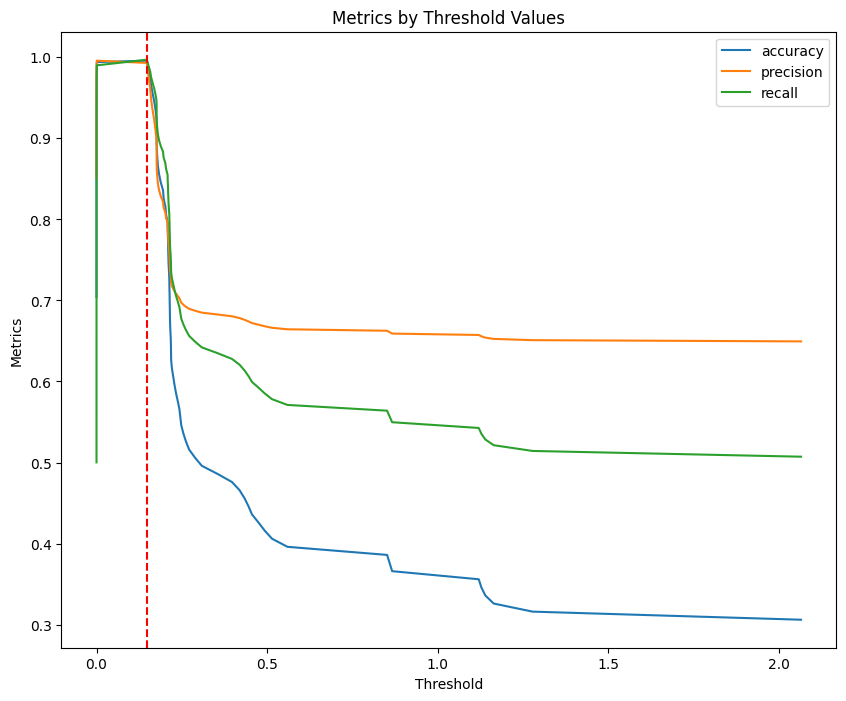

In [242]:
plt.figure(figsize=(10,8))
plt.plot(thresh_df['threshold'], thresh_df['accuracy'], label='accuracy')
plt.plot(thresh_df['threshold'], thresh_df['precision'], label='precision')
plt.plot(thresh_df['threshold'], thresh_df['recall'], label='recall')
plt.axvline(x=threshold, color='r', linestyle='dashed')
plt.xlabel('Threshold')
plt.ylabel('Metrics')
plt.title('Metrics by Threshold Values')
plt.legend()
plt.show()

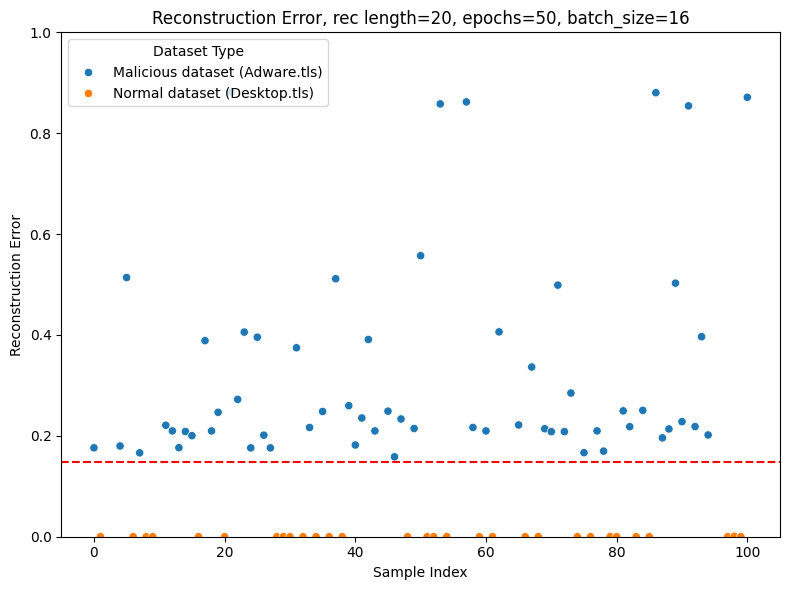

In [244]:
temp = recons_df.sample(frac=0.01, random_state=42).reset_index(drop=True)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=temp, x=temp.index, y='error', hue='y_true')
plt.axhline(y=threshold, color='r', linestyle='dashed')
plt.ylim(0, 1)  
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title(f'Reconstruction Error, rec length={RECORD_SEQUENCE_SIZE}, epochs=50, batch_size=16')
plt.legend(title='Dataset Type', loc='upper left')
plt.tight_layout()
plt.show()